# 1.0 Log Exploratory Data Analysis (EDA)
**Objective:** Analyze raw log event frequencies, template distributions, session length statistics, and Markov event transitions before training the LSTM model.

In [1]:
# ============================================================
# STEP 1: Imports & Setup
# ============================================================
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Ensure project root is in path
sys.path.append('..')
from src.config import PROCESSED_DATA_DIR, FIGURES_DIR

plt.style.use('seaborn-v0_8-darkgrid')
print("EDA Environment Ready.")

EDA Environment Ready.


In [2]:
# ============================================================
# STEP 2: Load Parsed Sessions Data
# ============================================================
with open('../data/processed/sessions.pkl', 'rb') as f:
    sessions, labels = pickle.load(f)

print(f"Total Sessions Analyzed: {len(sessions)}")
print(f"Normal Sessions:   {labels.count(0)}")
print(f"Anomalous Sessions: {labels.count(1)}")

Total Sessions Analyzed: 700
Normal Sessions:   500
Anomalous Sessions: 200


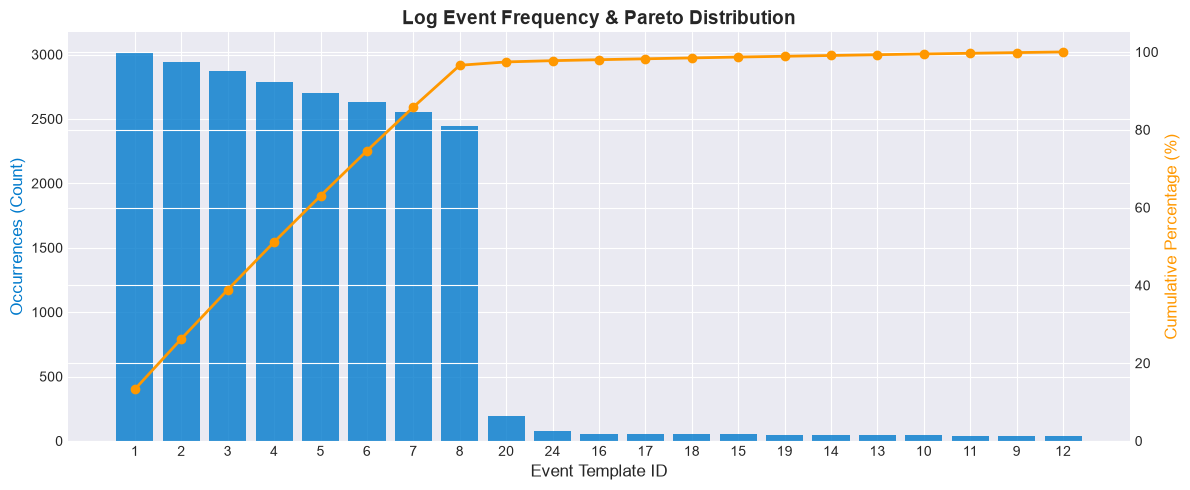

Total Log Lines Processed: 22734
Unique Event Templates:   21


In [3]:
# ============================================================
# STEP 3: Event Frequency Distribution (Pareto Analysis)
# ============================================================
all_events = [event for session in sessions for event in session]
event_counts = Counter(all_events)

df_events = pd.DataFrame(event_counts.items(), columns=['Event_ID', 'Frequency'])
df_events = df_events.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
df_events['Cumulative_Percentage'] = (df_events['Frequency'].cumsum() / df_events['Frequency'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(df_events['Event_ID'].astype(str), df_events['Frequency'], color='#007ACC', alpha=0.8)
ax1.set_xlabel('Event Template ID', fontsize=12)
ax1.set_ylabel('Occurrences (Count)', fontsize=12, color='#007ACC')

ax2 = ax1.twinx()
ax2.plot(df_events['Event_ID'].astype(str), df_events['Cumulative_Percentage'], color='#FF9800', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12, color='#FF9800')
ax2.set_ylim(0, 105)

plt.title('Log Event Frequency & Pareto Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/event_frequency_pareto.png', dpi=150)
plt.show()

print(f"Total Log Lines Processed: {len(all_events)}")
print(f"Unique Event Templates:   {len(event_counts)}")

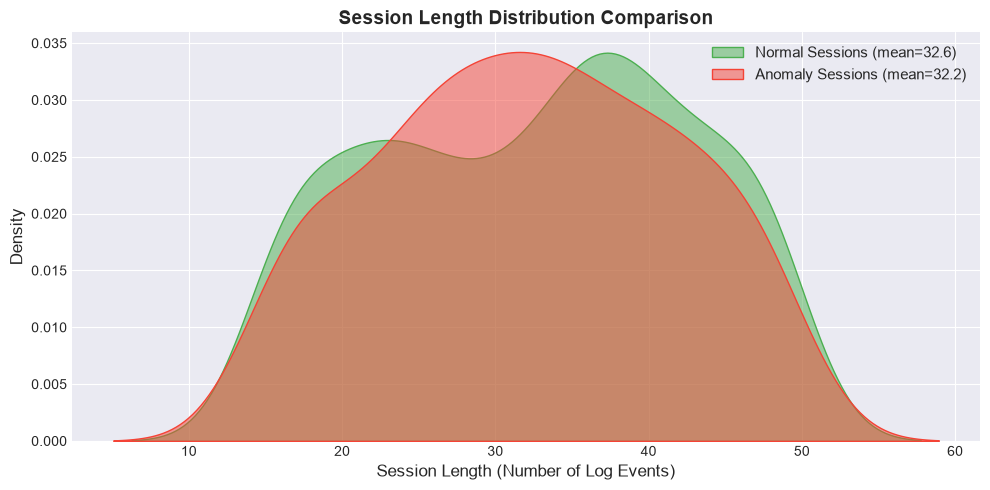

In [4]:
# ============================================================
# STEP 4: Session Length Distribution (Normal vs Anomaly)
# ============================================================
normal_lengths = [len(s) for s, l in zip(sessions, labels) if l == 0]
anomaly_lengths = [len(s) for s, l in zip(sessions, labels) if l == 1]

plt.figure(figsize=(10, 5))
sns.kdeplot(normal_lengths, fill=True, color='#4CAF50', label=f'Normal Sessions (mean={np.mean(normal_lengths):.1f})', alpha=0.5)
sns.kdeplot(anomaly_lengths, fill=True, color='#F44336', label=f'Anomaly Sessions (mean={np.mean(anomaly_lengths):.1f})', alpha=0.5)
plt.xlabel('Session Length (Number of Log Events)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Session Length Distribution Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/session_length_distribution.png', dpi=150)
plt.show()

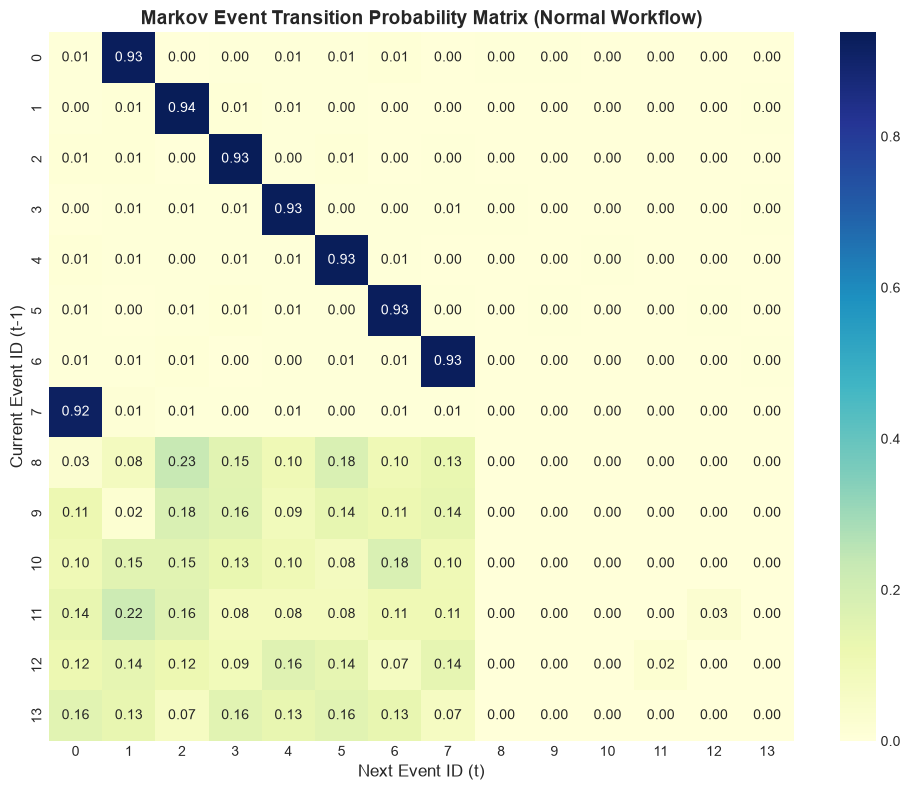

In [5]:
# ============================================================
# STEP 5: Markov Chain Transition Matrix
# ============================================================
# Calculate transition matrix P(event_t | event_{t-1})
max_event_id = max(all_events)
transition_matrix = np.zeros((max_event_id + 1, max_event_id + 1))

for sess, lab in zip(sessions, labels):
    if lab == 0: # Compute transitions for NORMAL execution only
        for i in range(len(sess) - 1):
            src, dst = sess[i], sess[i+1]
            transition_matrix[src, dst] += 1

# Normalize rows to probabilities
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
transition_prob_matrix = transition_matrix / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(transition_prob_matrix[1:15, 1:15], annot=True, fmt='.2f', cmap='YlGnBu', cbar=True)
plt.xlabel('Next Event ID (t)', fontsize=12)
plt.ylabel('Current Event ID (t-1)', fontsize=12)
plt.title('Markov Event Transition Probability Matrix (Normal Workflow)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/markov_transition_matrix.png', dpi=150)
plt.show()